# 1 Modelo ARMA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox



# ------------------------------
# 1. Cargar los datos
# ------------------------------
df = pd.read_csv('limpiezaPrecio3_Omie2020_2024.csv', sep=";")

# Ver las primeras filas
print(df.columns.tolist())
# ------------------------------
# 2. Preparar la serie temporal
# ------------------------------
# Convertir la columna de datetime a tipo datetime y ponerla como indice
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Ordenar por fecha por si acaso
df.sort_index(inplace=True)


# Seleccionamos la columna de precio (la que queremos predecir)
#serie = df['price']   # precio podria contener valores nulos, por si acaso
serie = df['price'].replace([np.inf, -np.inf], np.nan).dropna() #quitamos valores erroneos

# Comprobar si hay fechas u horas repetidas
print("¿Hay duplicados en el índice?", serie.index.duplicated().any())

duplicados = serie.index[serie.index.duplicated(keep=False)].unique()
print("Índices duplicados:", duplicados[:10])  # muestra los primeros 10 repetdos
# Asigna frecuencia, para nosostros h para una frecuencia en horas
serie = serie.asfreq('h')   # o 'd' para dias

['datetime', 'price', 'hour']
¿Hay duplicados en el índice? False
Índices duplicados: DatetimeIndex([], dtype='datetime64[us]', name='datetime', freq=None)


Tamaño entrenamiento: 39848 horas (1660 días)
Tamaño prueba:        4000 horas  (167 días)
Porcentaje test:      9.1%
                               SARIMAX Results                                
Dep. Variable:                  price   No. Observations:                39848
Model:                 ARIMA(2, 0, 1)   Log Likelihood             -151662.968
Date:                Sat, 25 Apr 2026   AIC                         303335.936
Time:                        14:17:29   BIC                         303378.901
Sample:                    01-01-2020   HQIC                        303349.538
                         - 07-18-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         93.0139      3.392     27.420      0.000      86.365      99.662
ar.L1        

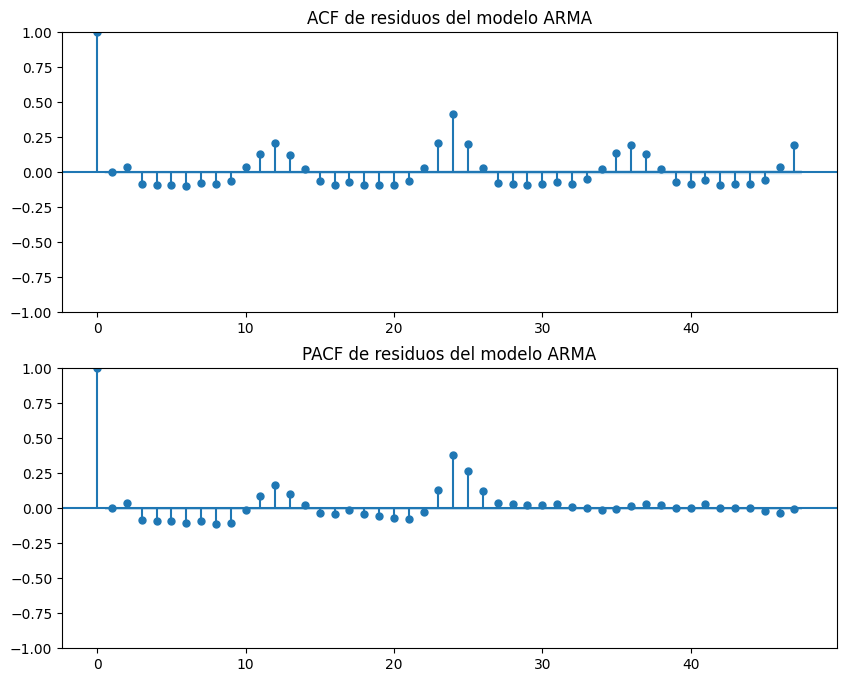


TEST LJUNG-BOX
       lb_stat  lb_pvalue
10  2132.60692        0.0
la serie NO es ruido blanco (tiene estructura/autocorrelacion)

========== MÉTRICAS DE PRECISIÓN ==========
  MAE   (Error Absoluto Medio):        33.3318 €/MWh
  RMSE  (Raíz Error Cuadrático Medio): 42.1562 €/MWh
  MAPE  (Error Porcentual Medio):       986792423041276544.00%
  R²    (Coeficiente determinación):    -0.0106
  RMSE modelo naive (benchmark):        13.9340 €/MWh
  → El modelo es PEOR que el naive



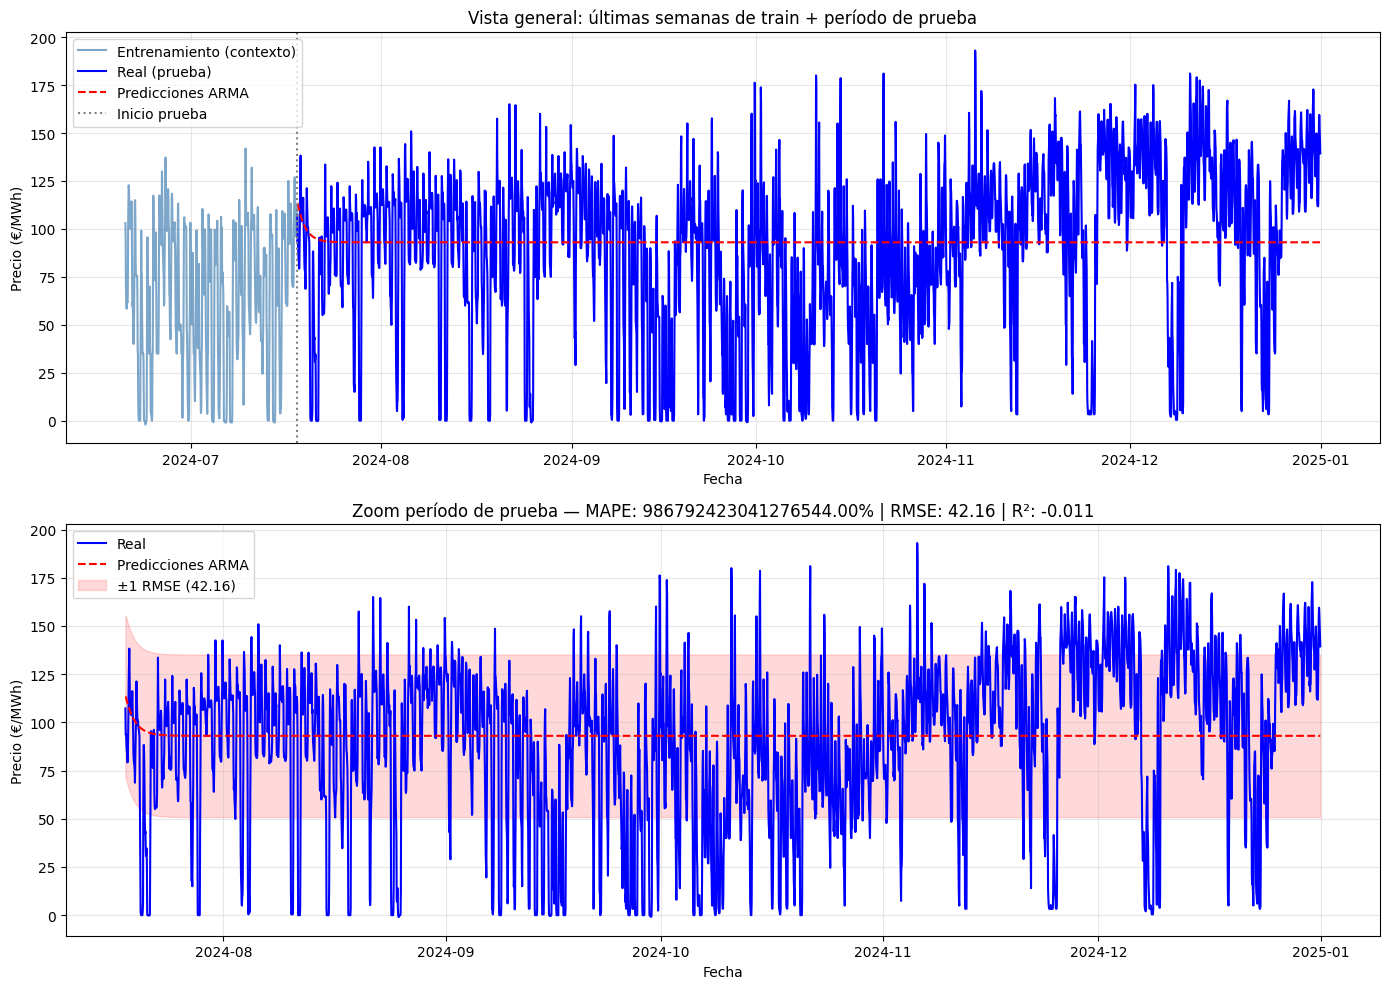

In [ ]:
# ==============================
# 4. CORREGIDO División en entrenamiento y prueba
# ==============================
# ultimas 2 semanas del dataset (336 horas) para test, mas representativo
TEST_HOURS = 4000  # 2 semanas

train = serie[:-TEST_HOURS]
test  = serie[-TEST_HOURS:]

print(f"Tamaño entrenamiento: {len(train)} horas ({len(train)/24:.0f} días)")
print(f"Tamaño prueba:        {len(test)} horas  ({len(test)/24:.0f} días)")
print(f"Porcentaje test:      {100*len(test)/len(serie):.1f}%")

# ==============================
# 5. Elegir los órdenes p y q del modelo ARMA
# ==============================
# En Box-Jenkins a partir de los gráficos de ACF y PACF, elegimos p y q
# En nuestro caso fueron p=2 y q=1
# Más adelante probar otros valores (ej. (2,0,1), etc.)
p = 2
q = 1
# En ARIMA, el orden es (p, d, q). Como usamos ARMA, d=0.
modelo = ARIMA(train, order=(p, 0, q))

# Ajustar el modelo
modelo_ajustado = modelo.fit()

# Mostrar un resumen del modelo
print(modelo_ajustado.summary())


# ==============================
# 5.2. Verificar residuos (validación)
# ==============================

# Verificar residuos (validación)
residuos = modelo_ajustado.resid

# Gráfico ACF de residuos
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(residuos, ax=axes[0])
axes[0].set_title('ACF de residuos del modelo ARMA')

plot_pacf(residuos, ax=axes[1])
axes[1].set_title('PACF de residuos del modelo ARMA')
plt.show()

# Prueba de Ljung-Box (si p-value > 0.05 los residuos son ruido blanco)
lb_test = acorr_ljungbox(residuos, lags=[10], return_df=True)
print(f"\nTEST LJUNG-BOX")
print(lb_test.to_string())
if (lb_test['lb_pvalue'] > 0.05).all():
    print("los residuos son ruido blanco")
else:
    print("los residuos NO son ruido blanco (tienen estructura/autocorrelacion)")

# ==============================
# 6. Predecir los valores del conjunto de prueba
# ==============================
# forecast recibe el número de pasos a predecir
predicciones = modelo_ajustado.forecast(steps=len(test))
predicciones.index = test.index   # para que luego se pueda gaficar bien

# ==============================
# 7. AMPLIADA - Métricas de precisión
# ==============================
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

mae  = mean_absolute_error(test, predicciones)
rmse = np.sqrt(mean_squared_error(test, predicciones))
mape = mean_absolute_percentage_error(test, predicciones) * 100

# Métrica adicional: R² (qué % de varianza explica el modelo)
ss_res = np.sum((test - predicciones) ** 2)
ss_tot = np.sum((test - test.mean()) ** 2)
r2 = 1 - (ss_res / ss_tot)

# Naive benchmark: predecir siempre el valor anterior (lag-1)
naive_pred = test.shift(1).dropna()
rmse_naive = np.sqrt(mean_squared_error(test[1:], naive_pred))

print("\n========== MÉTRICAS DE PRECISIÓN ==========")
print(f"  MAE   (Error Absoluto Medio):        {mae:.4f} €/MWh")
print(f"  RMSE  (Raíz Error Cuadrático Medio): {rmse:.4f} €/MWh")
print(f"  MAPE  (Error Porcentual Medio):       {mape:.2f}%")
print(f"  R²    (Coeficiente determinación):    {r2:.4f}")
print(f"  RMSE modelo naive (benchmark):        {rmse_naive:.4f} €/MWh")
print(f"  El modelo es {'MEJOR' if rmse < rmse_naive else 'PEOR'} que el naive")
print("============================================\n")

# ==============================
# 8. CORREGIDA - Gráficas con zoom y separadas
# ==============================
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# --- Gráfica 1: visión global (últimas 4 semanas de train + todo el test) ---
CONTEXTO = 672  # horas de entrenamiento que se muestran como contexto

ax1 = axes[0]
ax1.plot(train[-CONTEXTO:].index, train[-CONTEXTO:],
         label='Entrenamiento (contexto)', color='steelblue', alpha=0.7)
ax1.plot(test.index, test,
         label='Real (prueba)', color='blue', linewidth=1.5)
ax1.plot(test.index, predicciones,
         label='Predicciones ARMA', color='red', linestyle='--', linewidth=1.5)
ax1.axvline(x=test.index[0], color='gray', linestyle=':', linewidth=1.5,
            label='Inicio prueba')
ax1.set_title('Vista general: últimas semanas de train + período de prueba')
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Precio (€/MWh)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Gráfica 2: zoom solo en el período de prueba ---
ax2 = axes[1]
ax2.plot(test.index, test,
         label='Real', color='blue', linewidth=1.5)
ax2.plot(test.index, predicciones,
         label='Predicciones ARMA', color='red', linestyle='--', linewidth=1.5)
ax2.fill_between(test.index,
                 predicciones - rmse,
                 predicciones + rmse,
                 alpha=0.15, color='red', label=f'±1 RMSE ({rmse:.2f})')
ax2.set_title(f'Zoom período de prueba — MAPE: {mape:.2f}% | RMSE: {rmse:.2f} | R²: {r2:.3f}')
ax2.set_xlabel('Fecha')
ax2.set_ylabel('Precio (€/MWh)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('arma_prediccion.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
def buscar_mejor_orden(serie, max_p=5, max_q=5):
    """
    Busca el orden ARMA (p,q) que minimice AIC y pase Ljung-Box.
    """
    mejor_aic = np.inf
    mejor_orden = None
    mejor_modelo = None
    
    for p in range(max_p + 1):
        for q in range(max_q + 1):
            try:
                modelo = ARIMA(serie, order=(p, 0, q)).fit()
                residuos = modelo.resid.dropna()
                
                # Test Ljung-Box (lag=min(10, len(residuos)//5))
                lb = acorr_ljungbox(residuos, lags=min(10, len(residuos)//4))
                p_valor_min = lb['lb_pvalue'].min()  # El peor lag
                
                # Solo consideramos modelos donde residuos son ruido blanco
                if p_valor_min > 0.05:
                    if modelo.aic < mejor_aic:
                        mejor_aic = modelo.aic
                        mejor_orden = (p, q)
                        mejor_modelo = modelo
                        print(f"✓ ARMA({p},{q}): AIC={modelo.aic:.2f}, LB min p={p_valor_min:.4f}")
                else:
                    print(f"✗ ARMA({p},{q}): rechaza Ljung-Box (p mín={p_valor_min:.4f})")
                    
            except:
                continue
    
    if mejor_modelo:
        print(f"\n🏆 Mejor modelo: ARMA{mejor_orden} con AIC={mejor_aic:.2f}")
        return mejor_modelo
    else:
        print("\n⚠ No se encontró modelo que pase Ljung-Box. Prueba:")
        print("  - Aumentar max_p/max_q")
        print("  - Incluir diferenciación (SARIMA)")
        print("  - Transformar la serie (log, Box-Cox)")
        return None
    
modelo = buscar_mejor_orden(serie, max_p=5, max_q=5)

✗ ARMA(0,0): rechaza Ljung-Box (p mín=0.0000)


c:\Users\Jaime_Sanchez\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


✗ ARMA(0,1): rechaza Ljung-Box (p mín=0.0000)
✗ ARMA(0,2): rechaza Ljung-Box (p mín=0.0000)
✗ ARMA(0,3): rechaza Ljung-Box (p mín=0.0000)
✗ ARMA(0,4): rechaza Ljung-Box (p mín=0.0000)
✗ ARMA(0,5): rechaza Ljung-Box (p mín=0.0000)
✗ ARMA(1,0): rechaza Ljung-Box (p mín=0.0000)
✗ ARMA(1,1): rechaza Ljung-Box (p mín=0.0000)
✗ ARMA(1,2): rechaza Ljung-Box (p mín=0.0000)
✗ ARMA(1,3): rechaza Ljung-Box (p mín=0.0000)
✗ ARMA(1,4): rechaza Ljung-Box (p mín=0.0000)
✗ ARMA(1,5): rechaza Ljung-Box (p mín=0.0000)
✗ ARMA(2,0): rechaza Ljung-Box (p mín=0.0000)
✗ ARMA(2,1): rechaza Ljung-Box (p mín=0.0000)
✗ ARMA(2,2): rechaza Ljung-Box (p mín=0.0000)


c:\Users\Jaime_Sanchez\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


✗ ARMA(2,3): rechaza Ljung-Box (p mín=0.0000)


...

✗ ARMA(5,3): rechaza Ljung-Box (p mín=0.0000)


c:\Users\Jaime_Sanchez\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


✗ ARMA(5,4): rechaza Ljung-Box (p mín=0.0000)


c:\Users\Jaime_Sanchez\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


✗ ARMA(5,5): rechaza Ljung-Box (p mín=0.0000)

⚠ No se encontró modelo que pase Ljung-Box. Prueba:
  - Aumentar max_p/max_q
  - Incluir diferenciación (SARIMA)
  - Transformar la serie (log, Box-Cox)
